In [1]:
# ==========================================
# MedVisionAI - Pneumonia Detection
# NVIDIA Internship Project
# ==========================================

print("Welcome to MedVisionAI 🚀")

Welcome to MedVisionAI 🚀


In [2]:
import os
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [3]:
# ==========================================
# Check PyTorch Installation
# ==========================================

print("PyTorch Version :", torch.__version__)
print("CUDA Available  :", torch.cuda.is_available())
print("Device          :", "GPU" if torch.cuda.is_available() else "CPU")

PyTorch Version : 2.13.0+cpu
CUDA Available  : False
Device          : CPU


In [4]:
# ==========================================
# Project Configuration
# ==========================================

PROJECT_NAME = "MedVisionAI"

IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

NUM_CLASSES = 2

CLASS_NAMES = ["NORMAL", "PNEUMONIA"]

print("Project :", PROJECT_NAME)
print("Image Size :", IMAGE_SIZE)
print("Batch Size :", BATCH_SIZE)
print("Classes :", CLASS_NAMES)

Project : MedVisionAI
Image Size : (224, 224)
Batch Size : 32
Classes : ['NORMAL', 'PNEUMONIA']


In [5]:
# ==========================================
# Image Transformations
# ==========================================

transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor()
])

print(transform)

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [6]:
# ==========================================
# Dataset Path
# ==========================================

DATASET_PATH = "../data/chest_xray"

print("Dataset Path :", DATASET_PATH)

Dataset Path : ../data/chest_xray


In [7]:
# ==========================================
# Check Dataset
# ==========================================

if os.path.exists(DATASET_PATH):
    print("✅ Dataset Found")
else:
    print("❌ Dataset Not Found")

✅ Dataset Found


In [8]:
# ==========================================
# Load Dataset
# ==========================================

train_dataset = datasets.ImageFolder(
    root=os.path.join(DATASET_PATH, "train"),
    transform=transform
)

val_dataset = datasets.ImageFolder(
    root=os.path.join(DATASET_PATH, "val"),
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(DATASET_PATH, "test"),
    transform=transform
)

print("Datasets Loaded Successfully!")

Datasets Loaded Successfully!


In [9]:
# ==========================================
# Dataset Information
# ==========================================

print("Training Images :", len(train_dataset))
print("Validation Images :", len(val_dataset))
print("Testing Images :", len(test_dataset))

print("\nClasses :", train_dataset.classes)

print("\nClass Mapping :")
print(train_dataset.class_to_idx)

Training Images : 5216
Validation Images : 16
Testing Images : 624

Classes : ['NORMAL', 'PNEUMONIA']

Class Mapping :
{'NORMAL': 0, 'PNEUMONIA': 1}


In [10]:
# ==========================================
# Create DataLoaders
# ==========================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoaders Created Successfully!")

DataLoaders Created Successfully!


In [11]:
# ==========================================
# Check One Batch
# ==========================================

images, labels = next(iter(train_loader))

print("Image Batch Shape :", images.shape)
print("Labels Shape :", labels.shape)

print("Labels :")
print(labels)

Image Batch Shape : torch.Size([32, 3, 224, 224])
Labels Shape : torch.Size([32])
Labels :
tensor([1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0,
        0, 1, 1, 1, 1, 1, 1, 1])


In [12]:
# ==========================================
# Dataset Folders
# ==========================================

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
TEST_DIR = os.path.join(DATASET_PATH, "test")
VAL_DIR = os.path.join(DATASET_PATH, "val")

print("Train :", TRAIN_DIR)
print("Test  :", TEST_DIR)
print("Val   :", VAL_DIR)

Train : ../data/chest_xray\train
Test  : ../data/chest_xray\test
Val   : ../data/chest_xray\val


In [13]:
# ==========================================
# Verify Dataset Folders
# ==========================================

folders = [TRAIN_DIR, TEST_DIR, VAL_DIR]

for folder in folders:
    if os.path.exists(folder):
        print(f"✅ {folder} exists")
    else:
        print(f"❌ {folder} not found")

✅ ../data/chest_xray\train exists
✅ ../data/chest_xray\test exists
✅ ../data/chest_xray\val exists


In [14]:
# ==========================================
# Load Dataset (Run after downloading dataset)
# ==========================================

# train_dataset = datasets.ImageFolder(
#     root=TRAIN_DIR,
#     transform=transform
# )

# test_dataset = datasets.ImageFolder(
#     root=TEST_DIR,
#     transform=transform
# )

# val_dataset = datasets.ImageFolder(
#     root=VAL_DIR,
#     transform=transform
# )

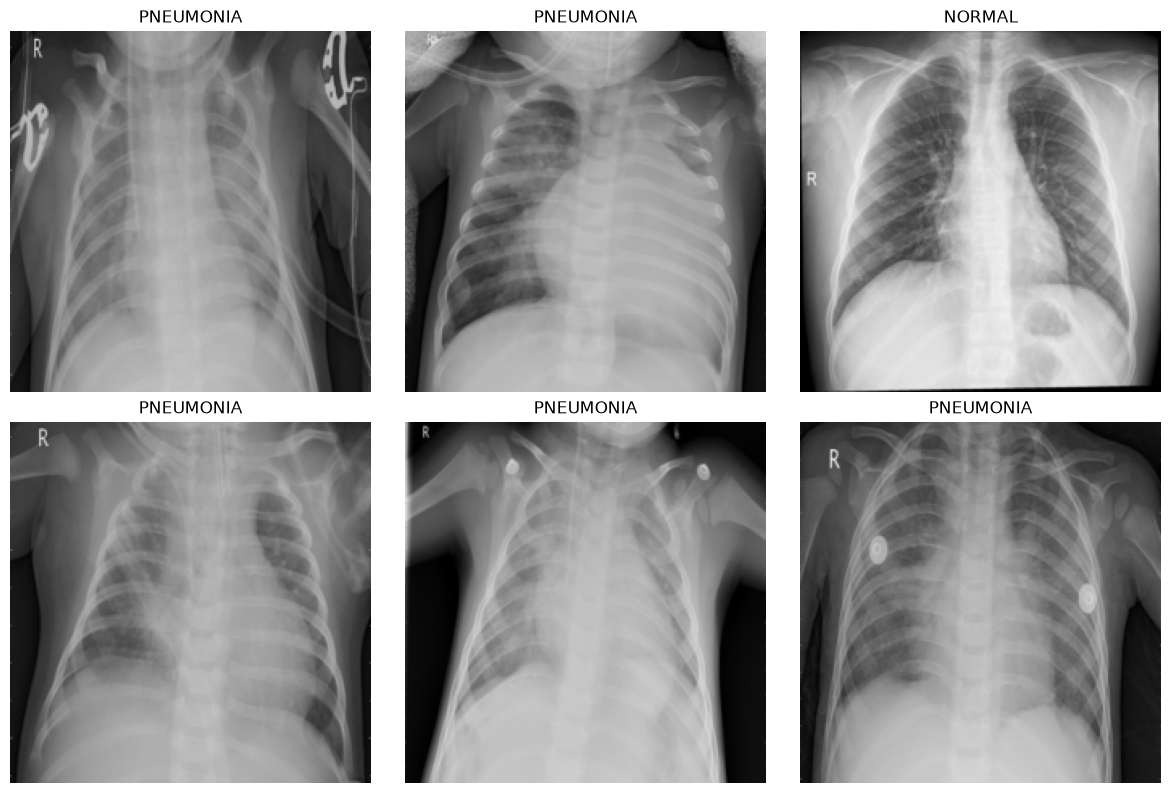

In [15]:
# ==========================================
# Display Sample Images
# ==========================================

import matplotlib.pyplot as plt

# Get one batch
images, labels = next(iter(train_loader))

# Display first 6 images
plt.figure(figsize=(12, 8))

for i in range(6):
    plt.subplot(2, 3, i + 1)

    # Convert image from Tensor to NumPy
    image = images[i].permute(1, 2, 0).numpy()

    plt.imshow(image)
    plt.title(CLASS_NAMES[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
# ==========================================
# Import Neural Network Module
# ==========================================

import torch.nn as nn

print("Neural Network Module Imported Successfully!")

Neural Network Module Imported Successfully!


In [38]:
# ==========================================
# Custom CNN Model
# ==========================================

class PneumoniaCNN(nn.Module):

    def __init__(self):

        super(PneumoniaCNN, self).__init__()

        self.features = nn.Sequential(

            # First Convolution Block

            nn.Conv2d(
                in_channels=3,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2),

            # Second Convolution Block

            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2)

        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                32 * 56 * 56,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                NUM_CLASSES
            )

        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [18]:
# ==========================================
# Create CNN Model
# ==========================================

model = PneumoniaCNN()

print("CNN Model Created Successfully!")

CNN Model Created Successfully!


In [19]:
# ==========================================
# Display Model Architecture
# ==========================================

print(model)

PneumoniaCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [20]:
# ==========================================
# Count Trainable Parameters
# ==========================================

total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

Total Parameters     : 12,850,530
Trainable Parameters : 12,850,530


In [21]:
# ==========================================
# Move Model to Device
# ==========================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)

print("Device :", device)

Device : cpu


In [22]:
# ==========================================
# Forward Pass Test
# ==========================================

images, labels = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print("Input Shape  :", images.shape)
print("Output Shape :", outputs.shape)

print("\nModel Output:\n")
print(outputs[:5])

Input Shape  : torch.Size([32, 3, 224, 224])
Output Shape : torch.Size([32, 2])

Model Output:

tensor([[0.0273, 0.0804],
        [0.0290, 0.0821],
        [0.0337, 0.0846],
        [0.0324, 0.0763],
        [0.0252, 0.0911]], grad_fn=<SliceBackward0>)


In [23]:
# ===========================================
# Define Loss Function
# ===========================================

criterion = nn.CrossEntropyLoss()

print("Loss Function Created Successfully!")
print(criterion)

Loss Function Created Successfully!
CrossEntropyLoss()


In [24]:
# ===========================================
# Define Optimizer
# ===========================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Optimizer Created Successfully!")
print(optimizer)

Optimizer Created Successfully!
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [25]:
# ===========================================
# Move Model to Device
# ===========================================

model = model.to(device)

print("Model moved to:", device)

Model moved to: cpu


In [26]:
# ===========================================
# Training Configuration
# ===========================================

NUM_EPOCHS = 10

train_losses = []

print("Training Configuration Ready!")
print("Epochs :", NUM_EPOCHS)

Training Configuration Ready!
Epochs : 10


In [27]:
# ===========================================
# Train the CNN Model
# ===========================================

for epoch in range(NUM_EPOCHS):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        # Move data to device
        images = images.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Accumulate loss
        running_loss += loss.item()

    # Average loss for this epoch
    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]  Loss: {epoch_loss:.4f}")

Epoch [1/10]  Loss: 0.3104
Epoch [2/10]  Loss: 0.1002
Epoch [3/10]  Loss: 0.0720
Epoch [4/10]  Loss: 0.0600
Epoch [5/10]  Loss: 0.0557
Epoch [6/10]  Loss: 0.0477
Epoch [7/10]  Loss: 0.0396
Epoch [8/10]  Loss: 0.0369
Epoch [9/10]  Loss: 0.0147
Epoch [10/10]  Loss: 0.0091


In [28]:
# ===========================================
# Save the Trained Model
# ===========================================

MODEL_PATH = "../models/pneumonia_cnn.pth"

torch.save(model.state_dict(), MODEL_PATH)

print("Model Saved Successfully!")
print("Saved at:", MODEL_PATH)

Model Saved Successfully!
Saved at: ../models/pneumonia_cnn.pth


In [29]:
# ===========================================
# Set Model to Evaluation Mode
# ===========================================

model.eval()

print("Model is now in Evaluation Mode!")

Model is now in Evaluation Mode!


In [30]:
# ===========================================
# Store Predictions and Labels
# ===========================================

all_predictions = []
all_labels = []

print("Prediction Lists Created Successfully!")

Prediction Lists Created Successfully!


In [31]:
# ===========================================
# Predict on Test Dataset
# ===========================================

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Predictions Completed!")

Predictions Completed!


In [32]:
# ===========================================
# Calculate Test Accuracy
# ===========================================

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(all_labels, all_predictions)

print(f"Test Accuracy : {accuracy * 100:.2f}%")

Test Accuracy : 74.84%


In [33]:
# ===========================================
# Confusion Matrix
# ===========================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_predictions)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 80 154]
 [  3 387]]


In [34]:
# ===========================================
# Classification Report
# ===========================================

from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=CLASS_NAMES
    )
)

              precision    recall  f1-score   support

      NORMAL       0.96      0.34      0.50       234
   PNEUMONIA       0.72      0.99      0.83       390

    accuracy                           0.75       624
   macro avg       0.84      0.67      0.67       624
weighted avg       0.81      0.75      0.71       624



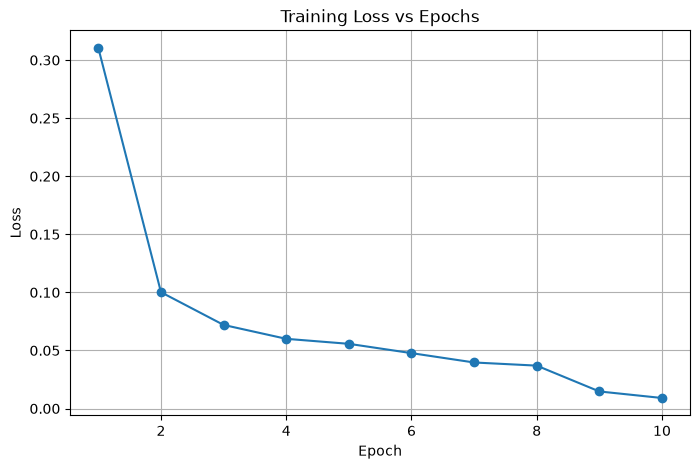

In [35]:
# ===========================================
# Plot Training Loss
# ===========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, NUM_EPOCHS + 1),
    train_losses,
    marker="o"
)

plt.title("Training Loss vs Epochs")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

In [36]:
# ===========================================
# Import Required Libraries
# ===========================================

from PIL import Image
import torchvision.transforms as transforms

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [37]:
# ===========================================
# Image Transform
# ===========================================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

print("Transform Ready!")

Transform Ready!


In [39]:
# ===========================================
# Load Saved Model
# ===========================================

MODEL_PATH = "../models/pneumonia_cnn.pth"

model.load_state_dict(torch.load(MODEL_PATH, map_location=torch.device("cpu")))

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [40]:
# ===========================================
# Set Model to Evaluation Mode
# ===========================================

model.eval()

print("Model is Ready for Prediction!")

Model is Ready for Prediction!


In [41]:
import os

image_path = "../data/chest_xray/test/NORMAL/IM-0001-0001.jpeg"

print(image_path)

../data/chest_xray/test/NORMAL/IM-0001-0001.jpeg


Image Loaded Successfully!


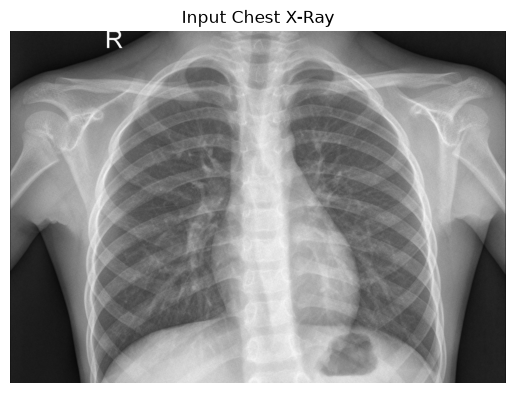

In [46]:
# ===========================================
# Load and Display Image
# ===========================================

from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(image_path).convert("RGB")

plt.imshow(image)
plt.axis("off")
plt.title("Input Chest X-Ray")

print("Image Loaded Successfully!")

In [47]:
# ===========================================
# Preprocess Image
# ===========================================

image_tensor = transform(image)

image_tensor = image_tensor.unsqueeze(0)

print("Image Shape :", image_tensor.shape)

Image Shape : torch.Size([1, 3, 224, 224])


In [48]:
# ===========================================
# Predict Image
# ===========================================

image_tensor = image_tensor.to(device)

with torch.no_grad():

    outputs = model(image_tensor)

    _, prediction = torch.max(outputs, 1)

print("Prediction Index :", prediction.item())

Prediction Index : 1


In [49]:
CLASS_NAMES = ["NORMAL", "PNEUMONIA"]

print("Predicted Class :", CLASS_NAMES[prediction.item()])

Predicted Class : PNEUMONIA


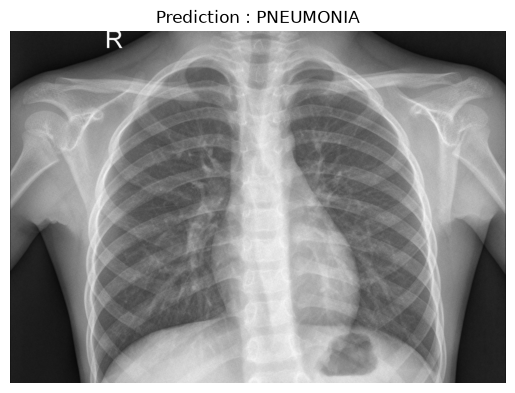

In [50]:
plt.imshow(image)
plt.title(f"Prediction : {CLASS_NAMES[prediction.item()]}")
plt.axis("off")
plt.show()